In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from experiments import run_eve_noise_comparison_experiment

In [2]:
df = run_eve_noise_comparison_experiment(
    n=5000,
    trials_per_scenario=30,
    eve_intercept_prob=0.10,
    channel_noise_prob=0.03
)

df

,scenario,eve_interception_rate,channel_noise_probability,average_qber,std_qber,trials_per_scenario,qubits_per_trial
0,Clean channel,0.0,0.00,0.000000,0.000000,30,5000
1,Noise only,0.0,0.03,0.028868,0.003882,30,5000
2,Eve only,0.1,0.00,0.025160,0.002648,30,5000
3,Eve + noise,0.1,0.03,0.053834,0.004441,30,5000


In [3]:
df.to_csv("../results/eve_noise_comparison_results.csv", index=False)

print("Saved results to ../results/eve_noise_comparison_results.csv")

Saved results to ../results/eve_noise_comparison_results.csv


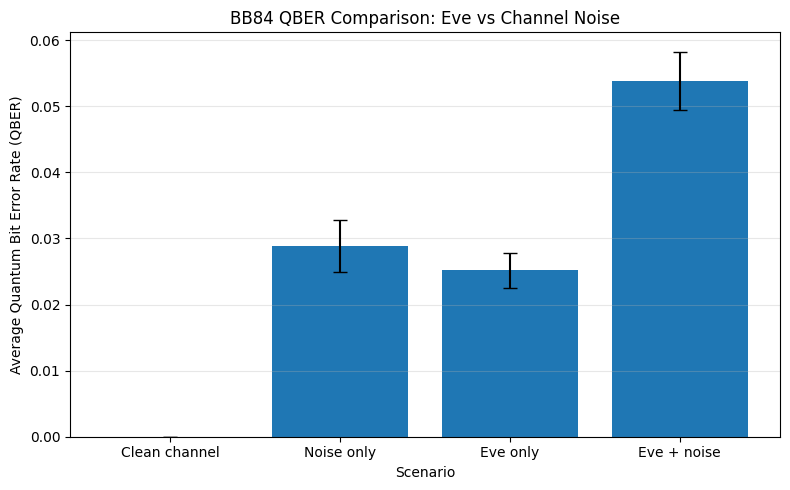

In [4]:
plt.figure(figsize=(8, 5))

plt.bar(
    df["scenario"],
    df["average_qber"],
    yerr=df["std_qber"],
    capsize=5
)

plt.xlabel("Scenario")
plt.ylabel("Average Quantum Bit Error Rate (QBER)")
plt.title("BB84 QBER Comparison: Eve vs Channel Noise")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("../figures/eve_noise_comparison_qber.png", dpi=300)
plt.show()

# Eve vs Channel Noise Comparison

This notebook compares BB84 QBER across four scenarios:

1. Clean channel
2. Noise only
3. Eve only
4. Eve + noise

The goal is to separate ordinary channel errors from errors caused by intercept-resend eavesdropping.

The results show that QBER is lowest in the clean channel, increases under channel noise, increases under Eve's intercept-resend attack, and is usually highest when both Eve and channel noise are present.